Analyze results from the pathway enrichment across all conditions and -omes

## Setup

### Imports

In [1]:
import os
from typing import Optional, Literal

import polars as pl
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt, rcParams, colors, cm

# set max font size 
rcParams["font.size"] = 7

### Constants

In [ ]:
# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "pathway_enrichment"
)

# directory for differentially expressed features
RESULTS_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_cache",
    "pathway_enrichment"
)

### Load Data

#### Helper Function: load all pathway enrichment results from specified comparison

In [5]:
def load_pathway_results(
    subset_id: str,
    direction: str
) -> Optional[pl.DataFrame] :
    # gather all of the results from the different databases and
    # sources of differentially expressed proteins
    all_results = [
        (
            pl.read_csv(results_f)
            .with_columns(
                (
                    pl.lit(block)
                    .alias("block")
                ),
                (
                    pl.concat_str(
                        pl.lit(f"[{db[0].upper()}]"),
                        pl.col("pathway_name"),
                        separator=" "
                    )
                    .alias("pathway_name")
                )
            )
            .select(
                "pathway_name",
                "block",
                "gene_count",
                "p_adjust",
                "gene_symbols",
                "pathway_genes"
            )
            .sort("p_adjust")
        )
        for db in ["hallmark", "kegg", "reactome"]
        for block in ["Transcriptomics", "Proteomics", "Lipid-Protein-Associations"]
        if os.path.isfile(results_f := os.path.join(   
                RESULTS_DIR,
                f"{db}/{subset_id}_{block}_{direction}.csv"
        ))
    ]
    if all_results:
        # filter the resulting pathways to remove any duplicate entries
        return (
            pl.concat(all_results)
            .sort(
                "p_adjust",
            )
            .group_by(
                "pathway_name",
                "block",
            )
            .agg(
                pl.col("gene_count").first(),
                pl.col("p_adjust").first(),
                pl.col("gene_symbols").first(),
                pl.col("pathway_genes").first()
            )
            .with_row_index()
        )
    # if no results, return None
    return None

#### Pre-load all of the pathway enrichment results

In [6]:
# key: (subset_id, direction)
# value: pathway_results_dataframe
results = {
    (subset_id, direction): r 
    for subset_id in [
        "B_NPM1-WT", "W_NPM1-WT", 
        #"B_FLT3-ITD-WT", "W_FLT3-ITD-WT", 
        #"B_FLT3-ITDxNPM1-WT", "W_FLT3-ITDxNPM1-WT"
    ]
    for direction in ["up", "down"]
    if (r := load_pathway_results(subset_id, direction)) is not None
}

#### Dump all of the pathways to a single arrow/CSV table

In [7]:
all_pathways = (
    pl.concat([
        (
           df
           .drop("index")
           .rename({
               "block": "omics_type"
           })
           .with_columns(
               pl.lit({"B": "Black", "W": "White"}[subset_id[0]]).alias("population"),
               pl.lit(subset_id.split("_", 1)[1]).alias("mutation_comparison"),
               pl.lit(direction).alias("direction"),
           )
        )
        for (subset_id, direction), df in results.items()
    ])
)
all_pathways

pathway_name,omics_type,gene_count,p_adjust,gene_symbols,pathway_genes,population,mutation_comparison,direction
str,str,i64,f64,str,str,str,str,str
"""[R] Hedgehog 'off' state""","""Proteomics""",5,0.001772,"""IFT140/TTC21B/WDR35/PSMB5/IFT1…","""ADCY1/ADCY10/ADCY2/ADCY3/ADCY4…","""Black""","""NPM1-WT""","""up"""
"""[R] Intraflagellar transport""","""Proteomics""",6,0.000006,"""IFT140/TTC21B/WDR35/TRAF3IP1/I…","""CLUAP1/DYNC2H1/DYNC2I1/DYNC2I2…","""Black""","""NPM1-WT""","""up"""
"""[R] Cilium Assembly""","""Proteomics""",7,0.000523,"""IFT140/TTC21B/WDR35/TRAF3IP1/T…","""ACTR1A/AHI1/AKAP9/ALMS1/ARF4/A…","""Black""","""NPM1-WT""","""up"""
"""[R] Signaling by Hedgehog""","""Proteomics""",5,0.004666,"""IFT140/TTC21B/WDR35/PSMB5/IFT1…","""ADAM17/ADCY1/ADCY10/ADCY2/ADCY…","""Black""","""NPM1-WT""","""up"""
"""[K] Salmonella infection""","""Transcriptomics""",6,0.041234,"""KPNA4/DCTN4/ACTR1B/PIK3C3/MAPK…","""ABI1/ACBD3/ACTB/ACTG1/ACTR10/A…","""Black""","""NPM1-WT""","""up"""
…,…,…,…,…,…,…,…,…
"""[K] Hematopoietic cell lineage""","""Proteomics""",7,0.000152,"""CD34/HLA-DRB4/HLA-DPA1/CD2/HLA…","""ANPEP/CD14/CD19/CD1A/CD1B/CD1C…","""White""","""NPM1-WT""","""down"""
"""[K] Rheumatoid arthritis""","""Proteomics""",5,0.002531,"""HLA-DRB4/HLA-DPA1/HLA-DQA1/HLA…","""ACP5/ANGPT1/ATP6AP1/ATP6V0A1/A…","""White""","""NPM1-WT""","""down"""
"""[K] Herpes simplex virus 1 inf…","""Proteomics""",6,0.005517,"""HLA-DRB4/HLA-DPA1/OAS2/HLA-DQA…","""AKT1/AKT2/AKT3/ALYREF/APAF1/B2…","""White""","""NPM1-WT""","""down"""


In [8]:
all_pathways.write_ipc(
    os.path.join(
        RESULTS_DIR,
        "pathways.arrow"
    )
)

In [9]:
all_pathways.write_csv(
    os.path.join(
        RESULTS_DIR,
        "pathways.csv"
    )
)

#### TODO
Automate uploading/updating the all pathways table (apache arrow + csv) to synapse (`syn74802869` and `syn74802870`, respectively). In the meantime, I manually uploaded them.

## Analysis
### Helper Functions

In [36]:
def v2c(
    v: float, 
    vmin: float, 
    vmax: float
) -> str : 
    """
    map a value to a color using the "coolwarm" colormap
    """
    return colors.to_hex(
        cm.ScalarMappable(
            norm=colors.Normalize(vmin=vmin, vmax=vmax), 
            cmap="bwr"
        ).to_rgba(v)  # type: ignore
    )

In [37]:
def overlap_factor(genes_a, genes_b):
    sa = set(genes_a.split("/"))
    sb = set(genes_b.split("/"))
    return len(sa & sb) / len(sa | sb)

In [82]:
def build_pathway_graph(
    r,
    min_node_size=5,
    min_overlap_factor=0.1,
    top_n_pathways=10
):
    # initialize graph
    g = nx.Graph()

    # add nodes (pathways, metrics as metadata)
    for i, p, b, n, pv in (
        r
        .select(pl.exclude("gene_symbols", "pathway_genes"))
        .filter(pl.col("gene_count") >= min_node_size)
        .sort("p_adjust")
        .head(top_n_pathways)
        .iter_rows()    
    ):
        g.add_node(
            i,
            name=p,
            block=b,
            n=n,
            p_value=pv
        )

    # add edges
    for i, pg_i in (
        r
        .filter(pl.col("gene_count") >= min_node_size)
        .sort("p_adjust")
        .head(top_n_pathways)
        .select("index", "pathway_genes")
        .iter_rows()    
    ):
        for j, pg_j in (
            r
            .filter(pl.col("gene_count") >= min_node_size)
            .sort("p_adjust")
            .head(top_n_pathways)
            .select("index", "pathway_genes")
            .iter_rows()    
        ):
            if (
                i != j 
                # only add edges for nodes with at least 10% overlap
                and (overlap := overlap_factor(pg_i, pg_j)) > min_overlap_factor
            ): 
                g.add_edge(
                    i,
                    j,
                    overlap=overlap
                )
    
    return g

In [83]:
def plot_pathway_network(
    g, 
    ax,
    direction: Literal["up", "down"],
    add_labels=True,
    label_rotation=-10,
) :

    pos = nx.kamada_kawai_layout(g, scale=10)

    nx.draw_networkx_edges(
        g, 
        pos, 
        ax=ax, 
        edge_color="#999999",
        width=[
            d["overlap"] * 5
            for *_, d in g.edges(data=True)
        ]
    )

    cmult = 1. if direction == "down" else -1.
    szmult = 1.

    nx.draw_networkx_nodes(
        g, 
        pos,  
        ax=ax,
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Transcriptomics"],
        node_color=[
            # take the first omics_type="proteomics" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Transcriptomics"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Transcriptomics"
        ],
        node_shape="^"
    )

    nx.draw_networkx_nodes(
        g, 
        pos, 
        ax=ax, 
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Proteomics"],
        node_color=[
            # take the first omics_type="proteomics" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Proteomics"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Proteomics"
        ],
        node_shape="s"
    )

    nx.draw_networkx_nodes(
        g, 
        pos,  
        ax=ax,
        nodelist=[n for n, d in g.nodes(data=True) if d["block"] == "Lipid-Protein-Associations"],
        node_color=[
            # take the first omics_type="Lipid-Protein-Associations" stat available
            v2c(
                cmult * np.log10(d["p_value"]),
                -4,
                4
            ) 
            for _, d in g.nodes(data=True) 
            if d["block"] == "Lipid-Protein-Associations"
        ],
        node_size=[
            d["n"] ** 2 * szmult
            for _, d in g.nodes(data=True) 
            if d["block"] == "Lipid-Protein-Associations"
        ],
        node_shape="o"
    )

    if add_labels:
        lbls = nx.draw_networkx_labels(
            g, 
            pos,
            {
                n: d["name"]
                for n, d in g.nodes(data=True)
            }, 
            ax=ax,
            font_size=7,
            font_family="Arial",
            horizontalalignment="left",
            verticalalignment="bottom", 
            clip_on=False
        )
        for _, text in lbls.items():
            text.set_verticalalignment("center")
            text.set_rotation_mode("anchor")
            text.set_rotation(label_rotation)

### Plot pathway overview

B_NPM1-WT down


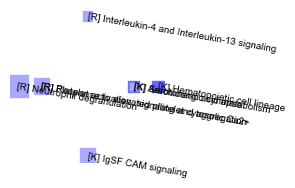

B_NPM1-WT up


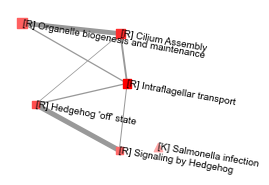

W_NPM1-WT down


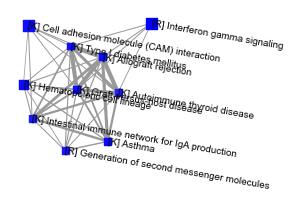

W_NPM1-WT up


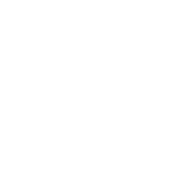

In [91]:
for subset_id, direction in [(f"{r}_NPM1-WT", d) for r in "BW" for d in ["down", "up"]]:
    print(subset_id, direction)

    fig, ax = plt.subplots(figsize=(2, 2))    

    if (r := results.get((subset_id, direction))) is not None:
        g = build_pathway_graph(r)
        plot_pathway_network(g, ax, direction, add_labels=True)
    ax.set_axis_off()

    plt.savefig(os.path.join(FIGURE_DIR, f"{subset_id}_{direction}_network.pdf"), dpi=400, bbox_inches="tight")
    plt.show()
    plt.close()

---

In [76]:
with pl.Config(set_tbl_rows=20):
    pexp_b = (
        all_pathways
        .filter(
            (pl.col("population") == "Black")
            #& (pl.col("gene_count") > 5)
        )
        .sort("p_adjust")
        .select(
            "pathway_name",
            "omics_type",
            (
                pl.col("direction")
                .replace_strict({
                    "up": "NPM1+",
                    "down": "NPM1-"
                })
                .alias("enriched in")
            ),
            "p_adjust",
            "gene_count",
            pl.col("gene_symbols").alias("diffex_genes"),
            "pathway_genes"
        )
    )
    display(pexp_b)
    pexp_b.write_csv(os.path.join(RESULTS_DIR, "black_NPM1-WT_enriched-pathways.csv"))

pathway_name,omics_type,enriched in,p_adjust,gene_count,diffex_genes,pathway_genes
str,str,str,f64,i64,str,str
"""[R] Intraflagellar transport""","""Proteomics""","""NPM1+""",0.000006,6,"""IFT140/TTC21B/WDR35/TRAF3IP1/I…","""CLUAP1/DYNC2H1/DYNC2I1/DYNC2I2…"
"""[R] Cilium Assembly""","""Proteomics""","""NPM1+""",0.000523,7,"""IFT140/TTC21B/WDR35/TRAF3IP1/T…","""ACTR1A/AHI1/AKAP9/ALMS1/ARF4/A…"
"""[R] Hedgehog 'off' state""","""Proteomics""","""NPM1+""",0.001772,5,"""IFT140/TTC21B/WDR35/PSMB5/IFT1…","""ADCY1/ADCY10/ADCY2/ADCY3/ADCY4…"
"""[R] Organelle biogenesis and m…","""Proteomics""","""NPM1+""",0.003315,7,"""IFT140/TTC21B/WDR35/TRAF3IP1/T…","""ACSS2/ACTR1A/AHI1/AKAP9/ALAS1/…"
"""[K] Hematopoietic cell lineage""","""Proteomics""","""NPM1-""",0.004184,8,"""CD34/CSF3R/CD14/CD8A/HLA-DQB1/…","""ANPEP/CD14/CD19/CD1A/CD1B/CD1C…"
"""[R] Signaling by Hedgehog""","""Proteomics""","""NPM1+""",0.004666,5,"""IFT140/TTC21B/WDR35/PSMB5/IFT1…","""ADAM17/ADCY1/ADCY10/ADCY2/ADCY…"
"""[K] Serotonergic synapse""","""Proteomics""","""NPM1-""",0.005786,8,"""GNG2/ALOX12/APP/PRKCA/MAOB/GNA…","""ADCY5/ALOX12/ALOX12B/ALOX15/AL…"
"""[K] Salmonella infection""","""Transcriptomics""","""NPM1+""",0.041234,6,"""KPNA4/DCTN4/ACTR1B/PIK3C3/MAPK…","""ABI1/ACBD3/ACTB/ACTG1/ACTR10/A…"
"""[R] Interleukin-4 and Interleu…","""Proteomics""","""NPM1-""",0.044063,7,"""JUNB/CEBPD/HGF/ICAM1/FOXO1/ALO…","""AKT1/ALOX15/ALOX5/ANXA1/BATF/B…"


In [78]:
with pl.Config(set_tbl_rows=40):
    pexp_w = (
        all_pathways
        .filter(
            (pl.col("population") == "White")
            & (pl.col("gene_count") >= 5)
        )
        .sort("p_adjust")
        .select(
            "pathway_name",
            "omics_type",
            (
                pl.col("direction")
                .replace_strict({
                    "up": "NPM1+",
                    "down": "NPM1-"
                })
                .alias("enriched in")
            ),
            "p_adjust",
            "gene_count",
            pl.col("gene_symbols").alias("diffex_genes"),
            "pathway_genes"
        )
    )
    display(pexp_w)
    pexp_w.write_csv(os.path.join(RESULTS_DIR, "white_NPM1-WT_enriched-pathways.csv"))

pathway_name,omics_type,enriched in,p_adjust,gene_count,diffex_genes,pathway_genes
str,str,str,f64,i64,str,str
"""[R] Interferon gamma signaling""","""Proteomics""","""NPM1-""",0.000027,8,"""HLA-DRB4/HLA-DPA1/OAS2/GBP4/GB…","""B2M/CAMK2A/CAMK2B/CAMK2D/CAMK2…"
"""[K] Asthma""","""Proteomics""","""NPM1-""",0.000152,5,"""HLA-DRB4/HLA-DPA1/HLA-DQA1/HLA…","""CCL11/CD40/CD40LG/EPX/FCER1A/F…"
"""[K] Hematopoietic cell lineage""","""Proteomics""","""NPM1-""",0.000152,7,"""CD34/HLA-DRB4/HLA-DPA1/CD2/HLA…","""ANPEP/CD14/CD19/CD1A/CD1B/CD1C…"
"""[K] Allograft rejection""","""Proteomics""","""NPM1-""",0.000166,5,"""HLA-DRB4/HLA-DPA1/HLA-DQA1/HLA…","""CD28/CD40/CD40LG/CD80/CD86/FAS…"
"""[K] Cell adhesion molecule (CA…","""Proteomics""","""NPM1-""",0.000166,8,"""CD34/ITGA9/HLA-DRB4/HLA-DPA1/C…","""ALCAM/CADM1/CADM3/CD2/CD22/CD2…"
"""[K] Type I diabetes mellitus""","""Proteomics""","""NPM1-""",0.000178,5,"""HLA-DRB4/HLA-DPA1/HLA-DQA1/HLA…","""CD28/CD80/CD86/CPE/FAS/FASLG/G…"
"""[K] Graft-versus-host disease""","""Proteomics""","""NPM1-""",0.000178,5,"""HLA-DRB4/HLA-DPA1/HLA-DQA1/HLA…","""CD28/CD80/CD86/FAS/FASLG/GZMB/…"
"""[R] Generation of second messe…","""Proteomics""","""NPM1-""",0.000246,5,"""HLA-DRB4/HLA-DPA1/EVL/HLA-DQA1…","""CD101/CD247/CD3D/CD3E/CD3G/CD4…"
"""[K] Intestinal immune network …","""Proteomics""","""NPM1-""",0.000258,5,"""HLA-DRB4/HLA-DPA1/HLA-DQA1/HLA…","""AICDA/CCL25/CCL28/CCR10/CCR9/C…"


In [ ]:
# rank the genes in each set based on their degree of being shared among different pathways
# and then do what with them?